In [ ]:
!pip install mgwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.8/396.8 kB 8.3 MB/s eta 0:00:00



--- Loading GeoJSON ---
Detected target column: 'Trip_log'
Detected feature columns: ['pop_log', 'pct_white', 'pct_18to34', 'pct_bachel', 'pct_no_veh', 'job_entrop', 'network_de', 'TripMiles_', 'pct_share']
Detected projected / metric centroids. No projection applied.

--- Preparing and cleaning attribute table ---
Loaded polygon dataset with 795 features and 9 independent variables (post-cleaning).

--- Training XGBRegressor (sklearn API) ---
XGBoost trained successfully.
Global R² (XGBoost, full data): 0.9708

--- Computing SHAP values (on full data) ---
SHAP interaction values computed (TreeExplainer).
Used TreeExplainer with booster.
SHAP values shape: (795, 11)
SHAP interactions shape: (795, 11, 11)

--- Computing Spatially Adjusted SHAP (SA-SHAP) ---
SA-SHAP computed by aggregating interactions with spatial components.

--- Saving per-feature CSVs ---
SA-SHAP contribution CSVs saved to: ./sa_shap_results

=== Feature Importance based on SA-SHAP (sorted desc) ===
   Feature  Mean

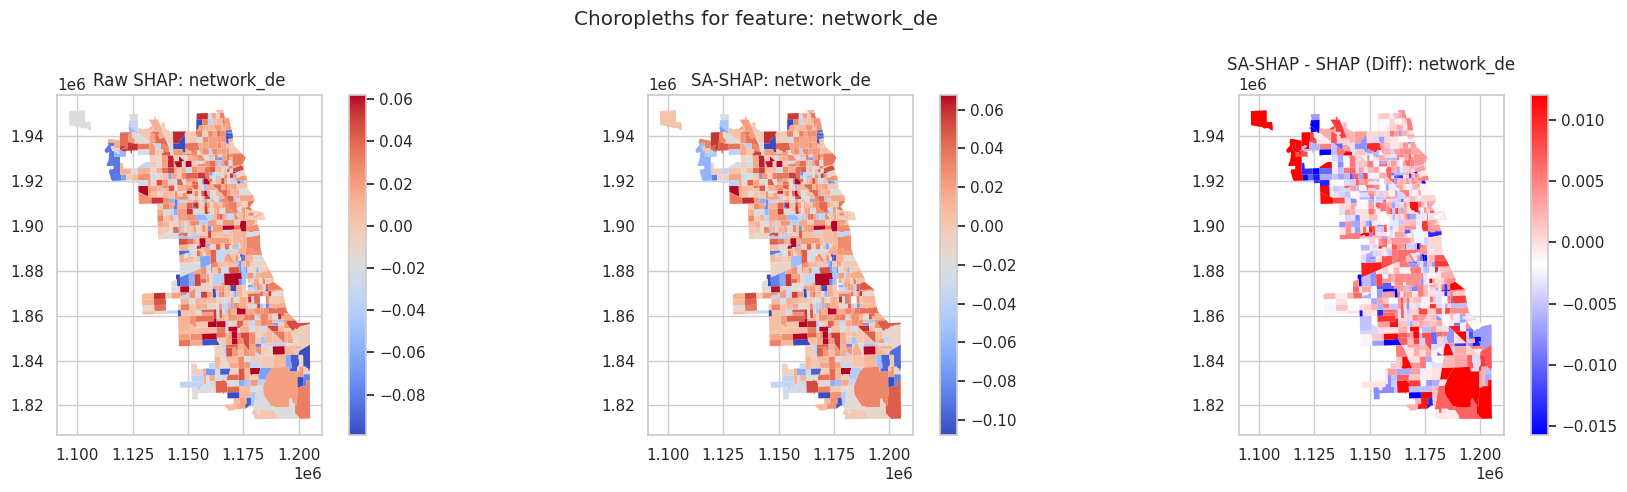

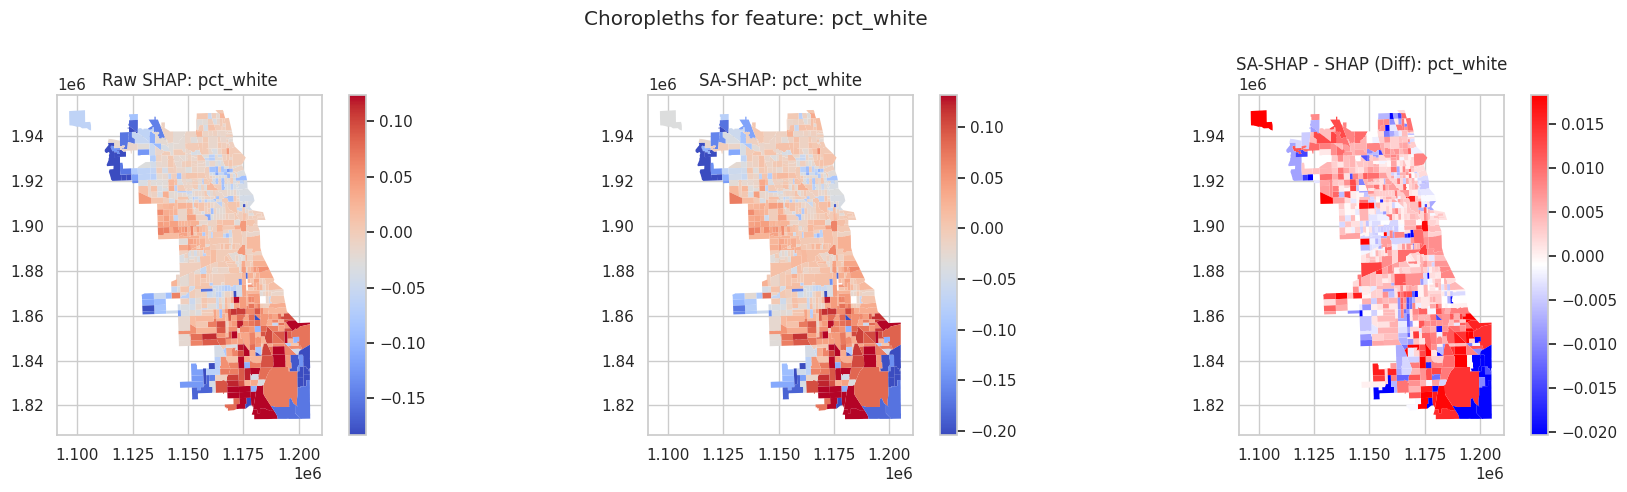

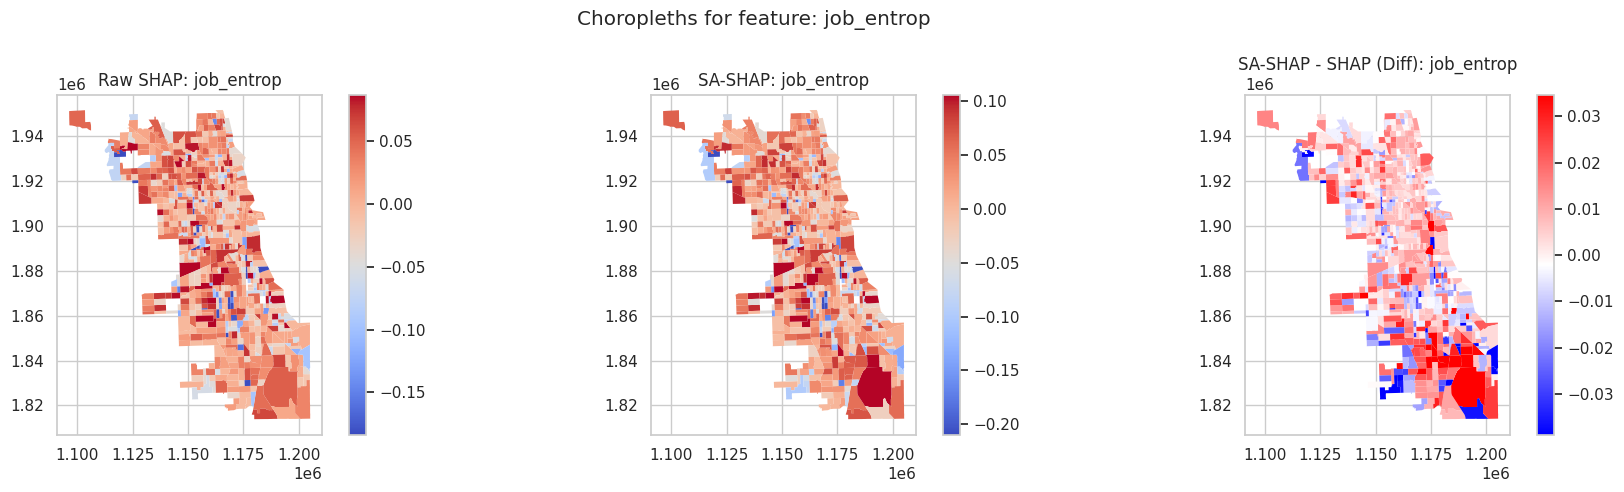

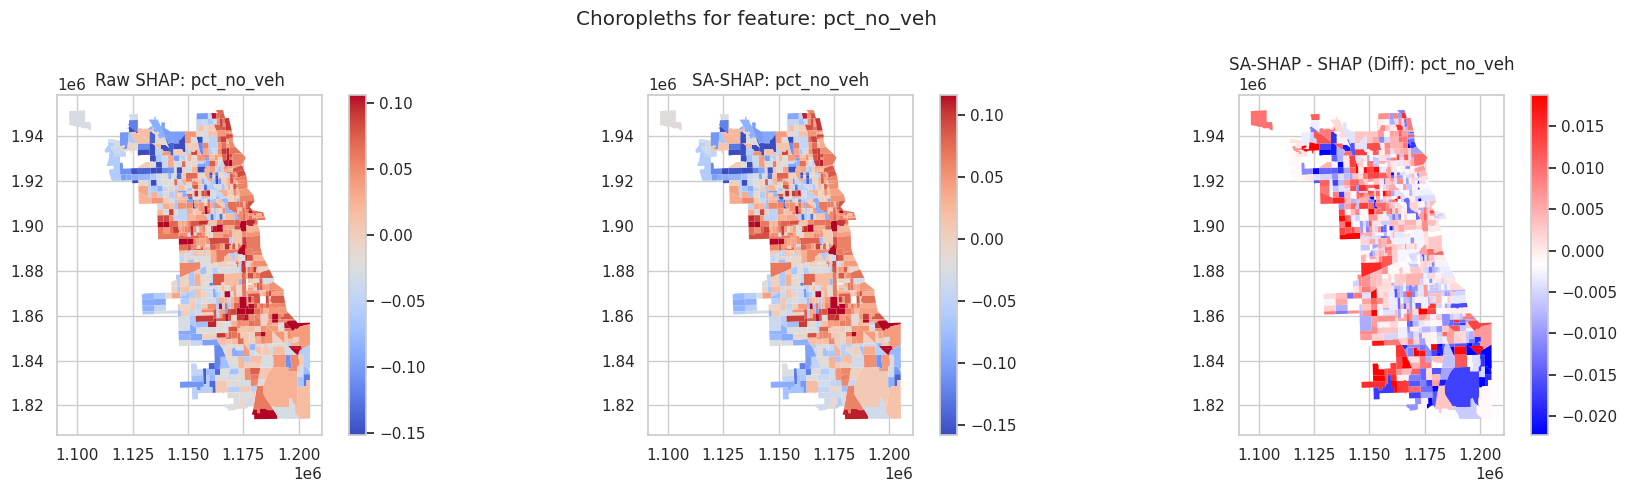

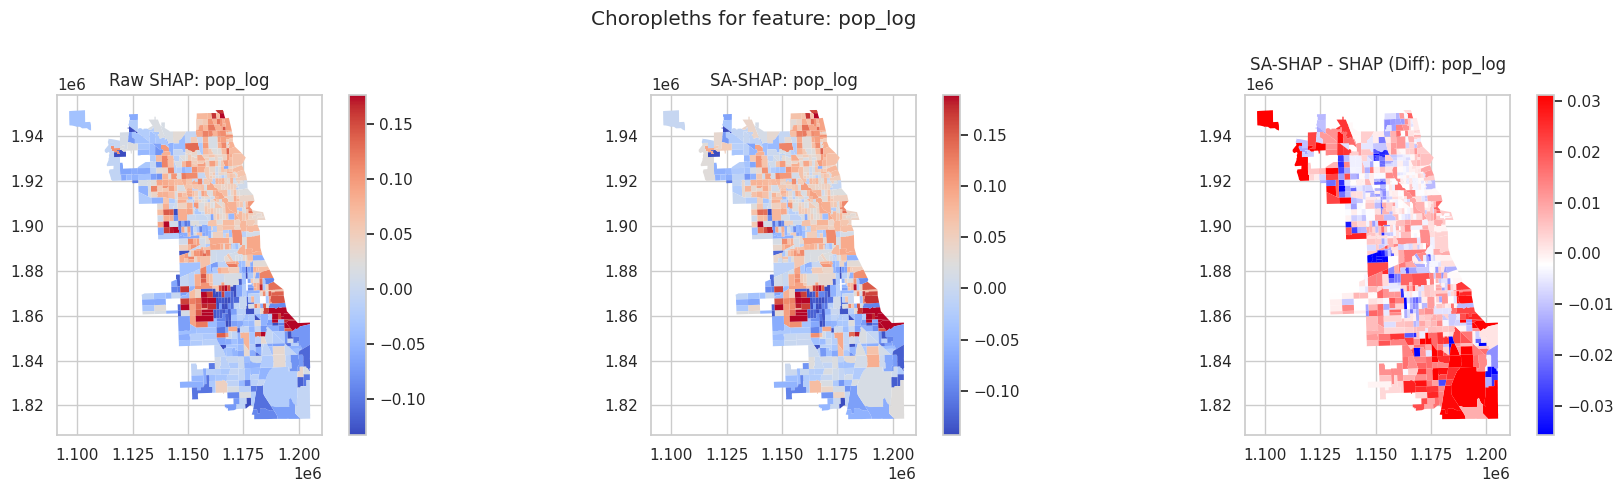

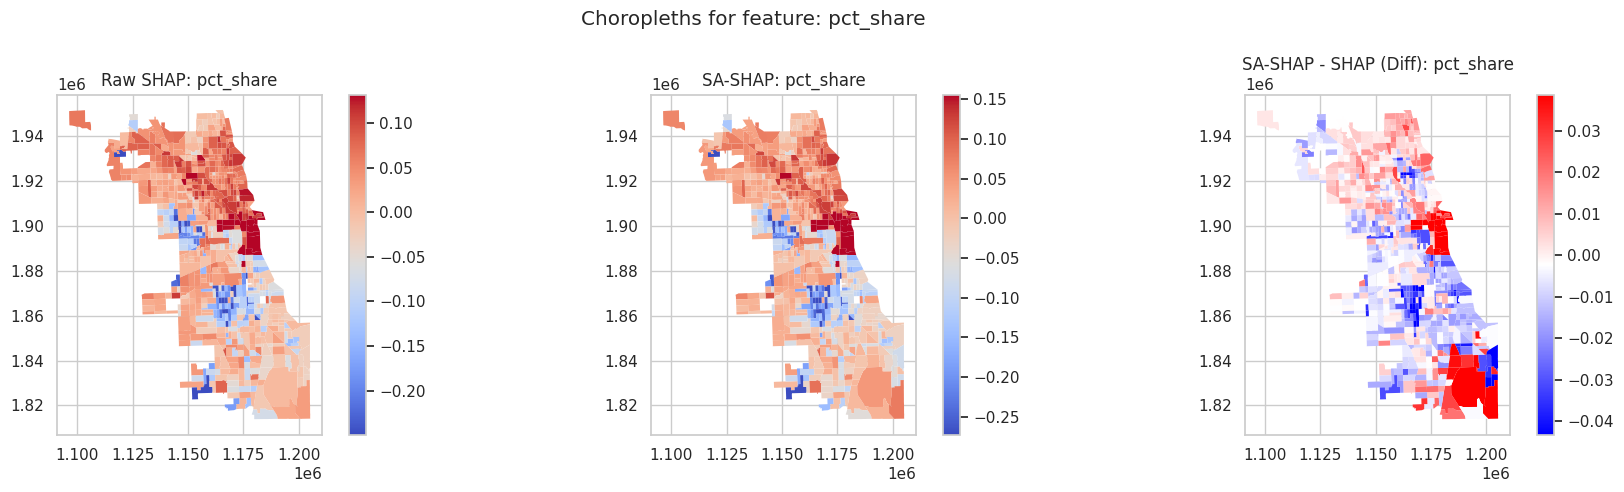

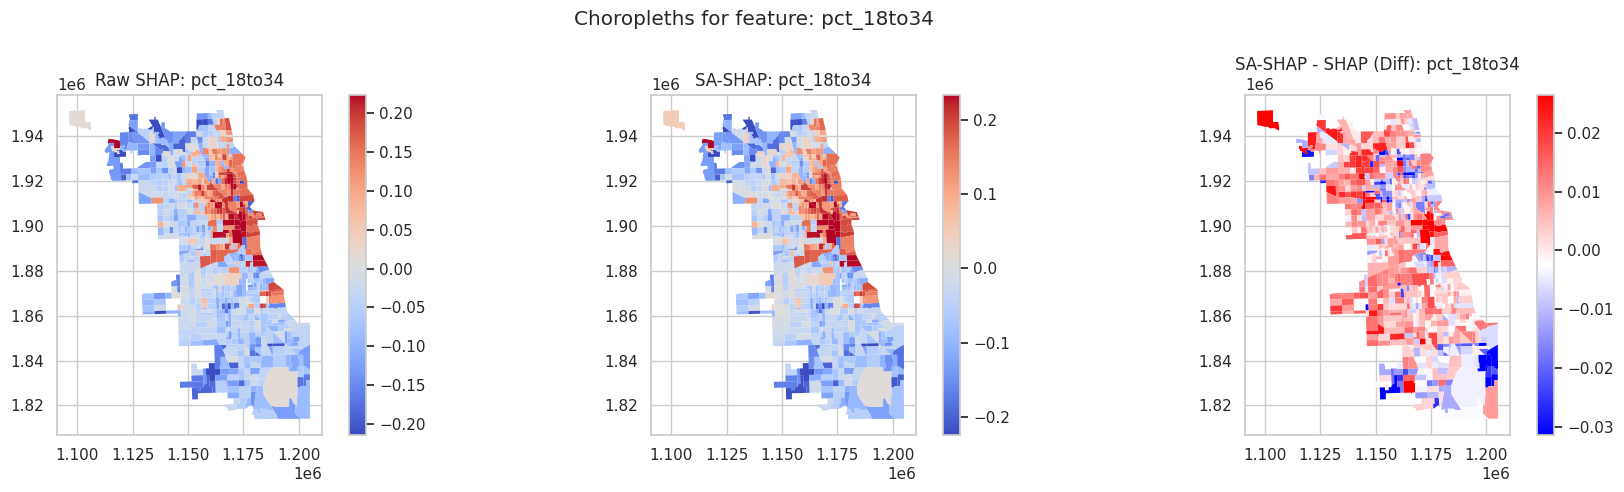

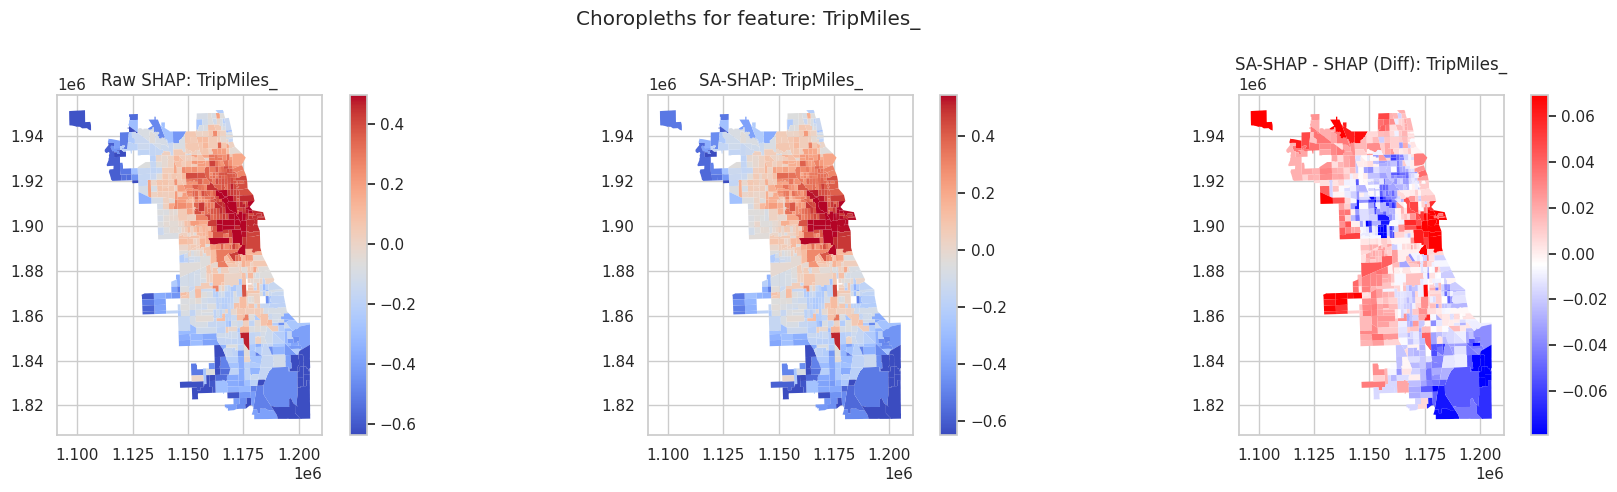

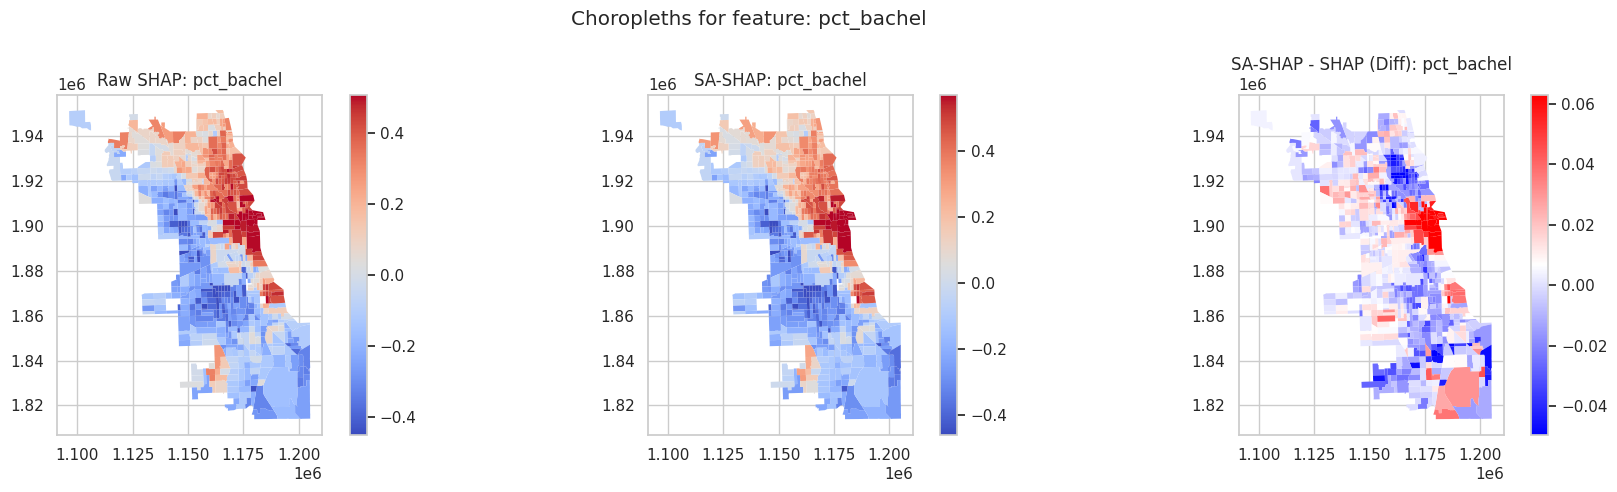

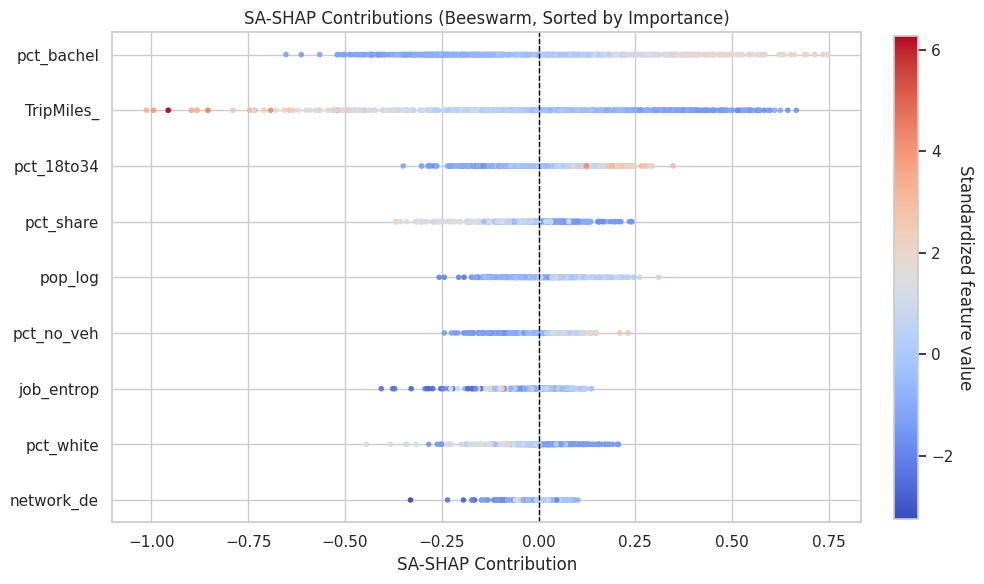


Saved GeoJSON with SA-SHAP attributes to: ./sa_shap_results/ride_with_sa_shap.geojson

✅ Program 2 completed successfully.
Explainer used: TreeExplainer(booster)


In [ ]:
# ============================================================
# Program 2 (Updated) : XGBoost + SA-SHAP for polygon GeoJSON
# - Reads polygons, uses centroids as spatial features
# - Cleans numeric attributes (handles NaN / inf / extreme outliers)
# - Trains XGBRegressor, computes SHAP (robust fallback)
# - Computes SA-SHAP by aggregating spatial interactions
# - Saves CSVs and produces maps + beeswarm
# ============================================================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ------------------------
# User config / paths
# ------------------------
geojson_path = "/content/drive/MyDrive/GWR/Ride.geojson"   # <- set your path
out_dir = "./sa_shap_results"
os.makedirs(out_dir, exist_ok=True)

# Train / val split proportion
val_frac = 0.15
random_state = 42

# XGBoost hyperparams (you can tune later)
xgb_params = dict(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state,
    verbosity=0,
    n_jobs=-1
)

# ------------------------
# 1) Read polygon GeoJSON and prepare attributes + centroids
# ------------------------
print("\n--- Loading GeoJSON ---")
gdf = gpd.read_file(geojson_path)
if gdf.empty:
    raise SystemExit("GeoDataFrame is empty. Check the input file.")

# assume first non-geometry column is the target; remaining non-geometry columns are features
non_geom_cols = [c for c in gdf.columns if c != gdf.geometry.name]
if len(non_geom_cols) < 2:
    raise SystemExit("Expect at least one target + one feature column in attributes.")

target_col = non_geom_cols[0]
feat_cols = non_geom_cols[1:]

print("Detected target column:", repr(target_col))
print("Detected feature columns:", feat_cols)

# Compute centroids (use geometry.centroid; for multipolygons it returns centroid)
centroids = gdf.geometry.centroid
# extract centroid coordinates
lon = centroids.x.values
lat = centroids.y.values

# Detect if coordinates are lon/lat (geographic) or already projected (metric)
def is_lonlat_array(arr):
    return (np.nanmin(arr) >= -180.0) and (np.nanmax(arr) <= 180.0)

is_geographic = is_lonlat_array(lon) and is_lonlat_array(lat)
if is_geographic:
    print("Detected geographic CRS (lon/lat). Projecting centroids to EPSG:3857 for metric distances...")
    transformer = Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
    X_proj, Y_proj = transformer.transform(lon, lat)
else:
    print("Detected projected / metric centroids. No projection applied.")
    X_proj, Y_proj = lon, lat

coords = np.column_stack([X_proj, Y_proj])

# ------------------------
# 2) Build attribute arrays and robust cleaning
# ------------------------
print("\n--- Preparing and cleaning attribute table ---")
# target
y_vec = gdf[target_col].values
# ensure numeric target
y_vec = pd.to_numeric(pd.Series(y_vec), errors="coerce").values
# features: copy to DataFrame to clean conveniently
X_raw_df = gdf[feat_cols].copy()

# 1) convert all feature columns to numeric (coerce errors -> NaN)
for c in X_raw_df.columns:
    X_raw_df[c] = pd.to_numeric(X_raw_df[c], errors="coerce")

# 2) replace inf / -inf with NaN
X_raw_df = X_raw_df.replace([np.inf, -np.inf], np.nan)

# 3) If target has NaNs -> drop those rows (can't train)
mask_valid_target = ~pd.isna(y_vec)
if mask_valid_target.sum() < len(y_vec):
    print(f"Warning: {len(y_vec) - mask_valid_target.sum()} rows with NaN target removed.")
    X_raw_df = X_raw_df.loc[mask_valid_target].reset_index(drop=True)
    y_vec = y_vec[mask_valid_target]
    coords = coords[mask_valid_target]
    X_proj = X_proj[mask_valid_target]; Y_proj = Y_proj[mask_valid_target]
    gdf = gdf.loc[mask_valid_target].reset_index(drop=True)

# 4) Fill NaN in features with column mean (after coercion)
X_raw_df = X_raw_df.fillna(X_raw_df.mean())

# 5) Clip extreme outliers to 0.1%/99.9% quantiles (robust)
def clip_extremes(col):
    low = col.quantile(0.001)
    high = col.quantile(0.999)
    return col.clip(lower=low, upper=high)

# X_raw_df = X_raw_df.apply(clip_extremes)   #OPTIONAL

# 6) Final check for Inf / NaN
if X_raw_df.isnull().any().any() or np.isinf(X_raw_df.values).any():
    raise SystemExit("Cleaning did not remove all NaN/Inf values - aborting.")

# Convert to numpy
X_raw = X_raw_df.values
feat_names = X_raw_df.columns.tolist()
n_features = X_raw.shape[1]

print(f"Loaded polygon dataset with {len(y_vec)} features and {n_features} independent variables (post-cleaning).")

# ------------------------
# 3) Standardize and build spatial features
# ------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

# spatial encoding: here use centroids (X_proj, Y_proj) — you can change to other encodings
X_spatial = coords
X_ml = np.column_stack([X_std, X_spatial])   # full matrix used for ML & SHAP
feat_names_full = feat_names + ["spatial_x", "spatial_y"]

# ------------------------
# 4) Train XGBRegressor (sklearn API)
# ------------------------
print("\n--- Training XGBRegressor (sklearn API) ---")
X_train, X_val, y_train, y_val = train_test_split(X_ml, y_vec, test_size=val_frac, random_state=random_state)

xgb_reg = XGBRegressor(**xgb_params)
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# global performance on full data
y_pred_full = xgb_reg.predict(X_ml)
r2_global = r2_score(y_vec, y_pred_full)
print("XGBoost trained successfully.")
print(f"Global R² (XGBoost, full data): {r2_global:.4f}")

# ------------------------
# 5) Compute SHAP values (robust) on FULL data (train+test)
# ------------------------
print("\n--- Computing SHAP values (on full data) ---")
use_tree_explainer = False
shap_values = None
shap_interactions = None
explainer_used = None

# Attempt 1: TreeExplainer with booster (fast for trees). Some xgboost versions can cause errors.
try:
    booster = xgb_reg.get_booster()
    explainer_tree = shap.TreeExplainer(booster)
    shap_values = explainer_tree.shap_values(X_ml)   # shape (n_samples, n_features_total)
    # attempt interactions (optional; can be large memory)
    try:
        shap_interactions = explainer_tree.shap_interaction_values(X_ml)
        shap_interactions = np.asarray(shap_interactions)
        print("SHAP interaction values computed (TreeExplainer).")
    except Exception as e_int:
        print("Warning: couldn't compute SHAP interaction values with TreeExplainer:", e_int)
        shap_interactions = None
    use_tree_explainer = True
    explainer_used = "TreeExplainer(booster)"
    print("Used TreeExplainer with booster.")
except Exception as e_tree:
    print("TreeExplainer(booster) failed with error:", e_tree)
    # Fallback: shap.Explainer using model.predict (model-agnostic sampling). More robust across versions.
    print("Falling back to shap.Explainer with model.predict and Independent masker.")
    try:
        masker = shap.maskers.Independent(X_ml, max_samples=500)  # controls sampling cost
        explainer_fallback = shap.Explainer(xgb_reg.predict, masker)
        shap_out = explainer_fallback(X_ml)
        shap_values = shap_out.values
        shap_interactions = None
        explainer_used = "shap.Explainer(predict, Independent(masker))"
        print("Used fallback shap.Explainer (Independent masker).")
    except Exception as e_fallback:
        print("Fallback shap.Explainer also failed:", e_fallback)
        raise SystemExit("SHAP computation failed; aborting.")

# normalize shap_values to numpy array
shap_values = np.asarray(shap_values)
print(f"SHAP values shape: {shap_values.shape}")
if shap_interactions is not None:
    print(f"SHAP interactions shape: {np.asarray(shap_interactions).shape}")

# ------------------------
# 6) Spatially Adjusted SHAP (SA-SHAP)
# ------------------------
print("\n--- Computing Spatially Adjusted SHAP (SA-SHAP) ---")
n_feat = X_std.shape[1]
idx_x = list(range(n_feat))
idx_spatial = list(range(n_feat, X_ml.shape[1]))  # indices of spatial columns in X_ml

if shap_interactions is not None:
    # shap_interactions expected shape: (n_samples, p, p)
    shap_adj_cols = []
    for j in idx_x:
        adj = shap_values[:, j].copy()
        # add interactions between feature j and each spatial feature s
        for s in idx_spatial:
            # shap_interactions might be (n, p, p) or list of arrays; handle via np.asarray
            adj += np.asarray(shap_interactions)[:, j, s]
        shap_adj_cols.append(adj)
    shap_adj_matrix = np.column_stack(shap_adj_cols)
    print("SA-SHAP computed by aggregating interactions with spatial components.")
else:
    # no interactions available -> fall back to raw SHAP for feature columns only
    shap_adj_matrix = shap_values[:, idx_x].copy()
    print("No SHAP interactions available; SA-SHAP = raw SHAP for feature columns.")

# ------------------------
# 7) Save per-feature CSVs (centroids + contributions)
# ------------------------
print("\n--- Saving per-feature CSVs ---")
for j, name in enumerate(feat_names):
    out_df = pd.DataFrame({
        "lon_centroid": lon,
        "lat_centroid": lat,
        "X_proj": X_proj,
        "Y_proj": Y_proj,
        f"SHAP_contrib_{name}": shap_values[:, j] if shap_values.shape[1] >= (j+1) else np.nan,
        f"SA_SHAP_contrib_{name}": shap_adj_matrix[:, j]
    })
    out_path = os.path.join(out_dir, f"sa_shap_contrib_{name}.csv")
    out_df.to_csv(out_path, index=False)
print("SA-SHAP contribution CSVs saved to:", out_dir)

# ------------------------
# 8) Feature importance percentages & sorting (based on SA-SHAP)
# ------------------------
mean_abs_contrib = np.mean(np.abs(shap_adj_matrix), axis=0)
percent_contrib = 100.0 * mean_abs_contrib / (mean_abs_contrib.sum() if mean_abs_contrib.sum() != 0 else 1.0)
df_imp = pd.DataFrame({
    "Feature": feat_names,
    "Mean |Contribution|": mean_abs_contrib,
    "Percent (%)": percent_contrib
}).sort_values("Mean |Contribution|", ascending=False).reset_index(drop=True)

print("\n=== Feature Importance based on SA-SHAP (sorted desc) ===")
print(df_imp.to_string(index=False))

#sorted_feats = df_imp["Feature"].tolist()
sorted_feats = df_imp["Feature"].tolist()[::-1]  # reverse sort
sorted_indices = [feat_names.index(f) for f in sorted_feats]

# ------------------------
# 9) Attach SHAP / SA-SHAP / Diff to GeoDataFrame and map
# ------------------------
print("\n--- Attaching results to GeoDataFrame and plotting choropleths ---")
# add (safe) columns to gdf (ensure same length)
for j, name in enumerate(feat_names):
    gdf[f"SA_SHAP_{name}"] = shap_adj_matrix[:, j]
    # raw shap: some shap_values arrays may include spatial columns at the end; take if available
    if shap_values.shape[1] >= (j+1):
        gdf[f"SHAP_{name}"] = shap_values[:, j]
    else:
        gdf[f"SHAP_{name}"] = np.nan
    gdf[f"DIFF_{name}"] = gdf[f"SA_SHAP_{name}"] - gdf[f"SHAP_{name}"]

# For each feature produce three choropleth maps (SHAP, SA-SHAP, DIFF)
cmap = "coolwarm"
for j, name in enumerate(sorted_feats):
    col_shap = f"SHAP_{name}"
    col_sa = f"SA_SHAP_{name}"
    col_diff = f"DIFF_{name}"
    # compute vmin/vmax using percentiles for better color stretching
    vmin = np.nanpercentile(gdf[col_sa], 2)
    vmax = np.nanpercentile(gdf[col_sa], 98)
    vmin_s = np.nanpercentile(gdf[col_shap], 2)
    vmax_s = np.nanpercentile(gdf[col_shap], 98)
    vmin_d = np.nanpercentile(gdf[col_diff], 2)
    vmax_d = np.nanpercentile(gdf[col_diff], 98)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    gdf.plot(column=col_shap, ax=axs[0], edgecolor="none", cmap=cmap, vmin=vmin_s, vmax=vmax_s, legend=True)
    axs[0].set_title(f"Raw SHAP: {name}")
    gdf.plot(column=col_sa, ax=axs[1], edgecolor="none", cmap=cmap, vmin=vmin, vmax=vmax, legend=True)
    axs[1].set_title(f"SA-SHAP: {name}")
    gdf.plot(column=col_diff, ax=axs[2], edgecolor="none", cmap="bwr", vmin=vmin_d, vmax=vmax_d, legend=True)
    axs[2].set_title(f"SA-SHAP - SHAP (Diff): {name}")
    plt.suptitle(f"Choropleths for feature: {name}")
    plt.tight_layout()
    plt.show()

# ------------------------
# 10) Beeswarm plot (SA-SHAP), sorted by importance, with colorbar
# ------------------------


sns.set(style="whitegrid")

# ---------- Function: Beeswarm with Correct Colorbar ----------
def plot_beeswarm_with_colorbar(ax, contrib_matrix, X_for_color, feature_names, cmap='coolwarm'):
    cmap_fn = cm.get_cmap(cmap)

    # -------- Global normalization across ALL features --------
    global_min = np.nanmin(X_for_color)
    global_max = np.nanmax(X_for_color)
    norm = plt.Normalize(global_min, global_max)

    sc_last = None

    # -------- Draw points feature by feature --------
    for i, name in enumerate(feature_names):
        x_vals = contrib_matrix[:, i]
        color_col = X_for_color[:, i]

        sc_last = ax.scatter(
            x_vals,
            np.ones_like(x_vals) * i,
            c=cmap_fn(norm(color_col)),
            s=16,
            alpha=0.95,
            edgecolors='none'
        )

    # -------- Correct colorbar using ScalarMappable --------
    cbar = plt.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap_fn),
        ax=ax,
        fraction=0.03,
        pad=0.04
    )
    cbar.set_label("Standardized feature value", rotation=270, labelpad=15)

    # -------- Axes settings --------
    ax.set_yticks(np.arange(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("SA-SHAP Contribution")
    ax.grid(True, axis='x')


# ---------- Call beeswarm plot with sorted features ----------
fig, ax = plt.subplots(figsize=(10, 6))
plot_beeswarm_with_colorbar(
    ax,
    shap_adj_matrix[:, sorted_indices],   # SA-SHAP values sorted
    X_std[:, sorted_indices],             # scaled features sorted
    sorted_feats                          # names sorted
)
ax.set_title("SA-SHAP Contributions (Beeswarm, Sorted by Importance)")
plt.tight_layout()
plt.show()


# ------------------------
# 11) (Optional) Save GeoJSON with SA-SHAP attributes
# ------------------------
out_geojson = os.path.join(out_dir, "ride_with_sa_shap.geojson")
gdf.to_file(out_geojson, driver="GeoJSON")
print(f"\nSaved GeoJSON with SA-SHAP attributes to: {out_geojson}")

print("\n✅ Program 2 completed successfully.")
print("Explainer used:", explainer_used)



--- Plotting Binned SHAP vs SA-SHAP (100-bin smooth curves) ---


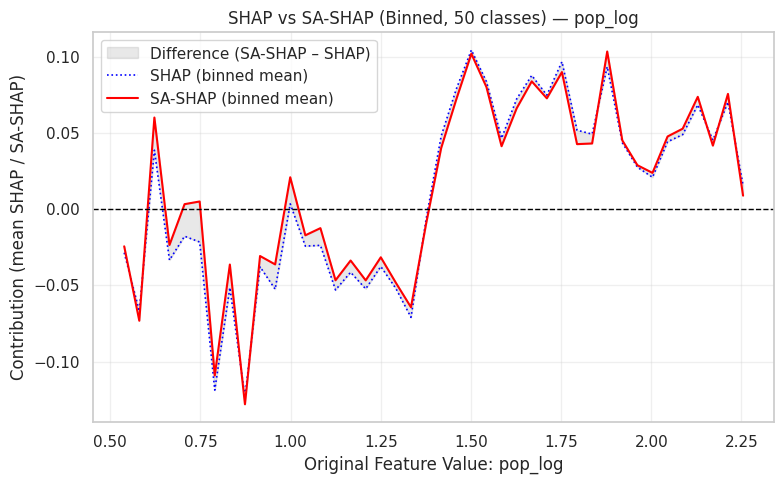

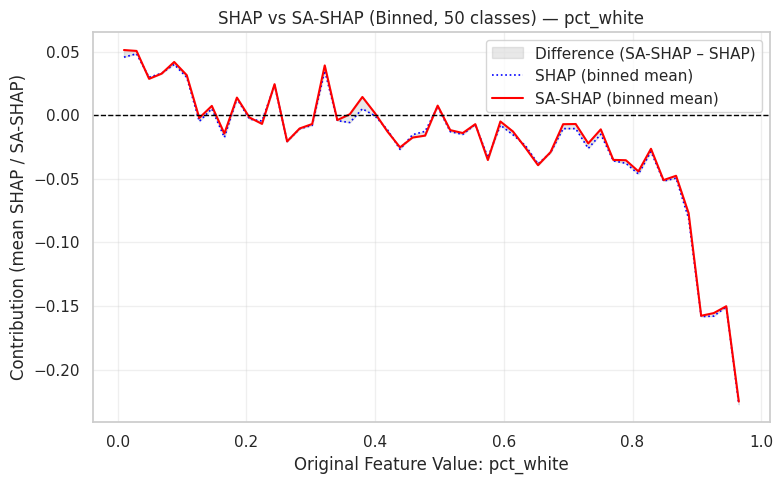

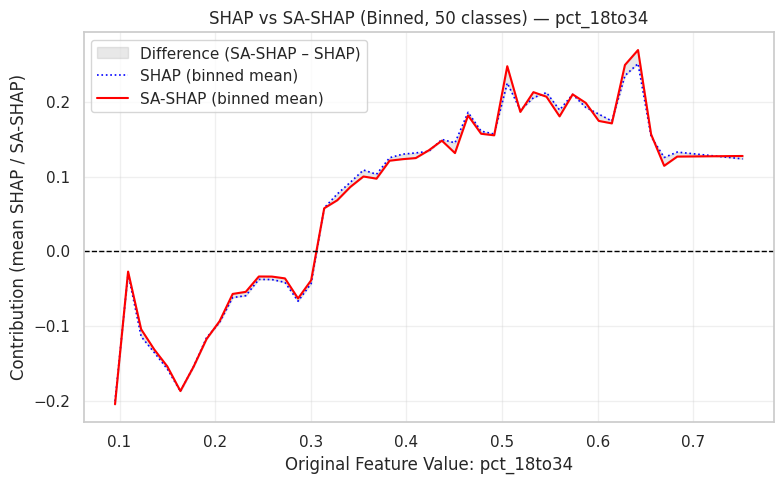

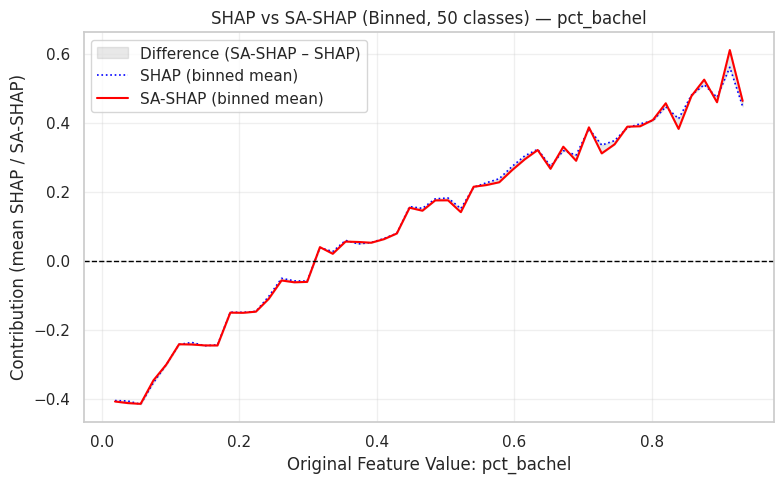

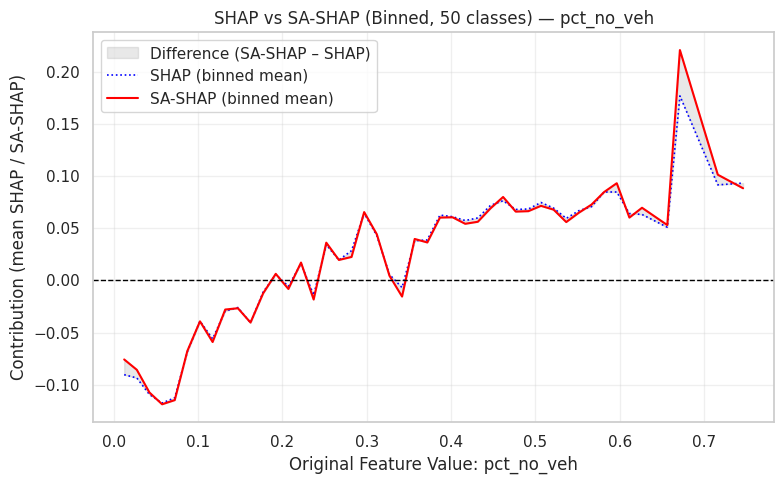

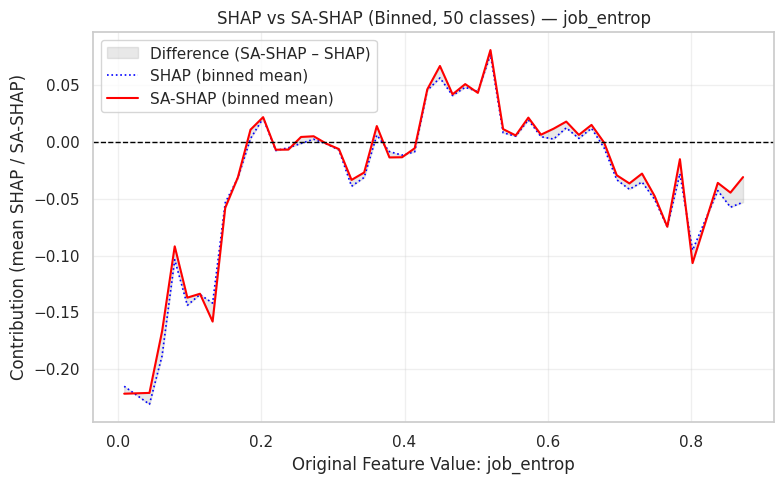

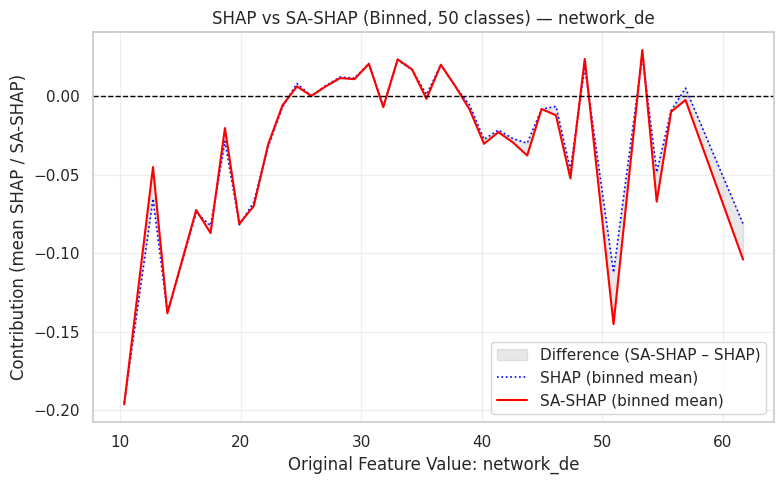

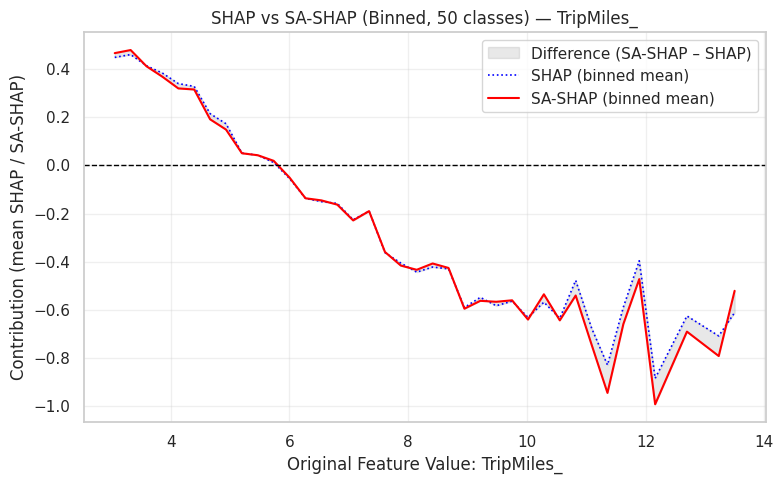

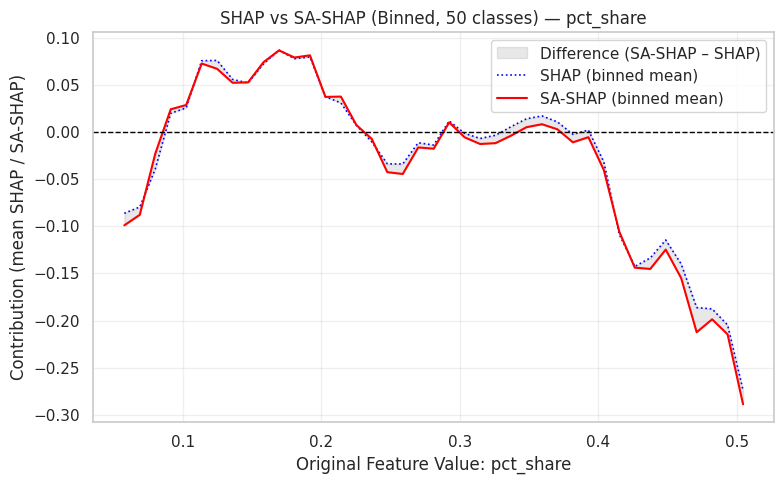


All binned SHAP plots saved in ./sa_shap_plots_binned/


In [ ]:
# ============================================================
#  New: Binned SHAP vs SA-SHAP plot (for smoother presentations)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

print("\n--- Plotting Binned SHAP vs SA-SHAP (100-bin smooth curves) ---")

os.makedirs("./sa_shap_plots_binned", exist_ok=True)

k_bins = 50  # number of bins (you may change to 50, 200, ...)

for j, fname in enumerate(feat_names):

    # Original feature values (not standardized)
    x_vals = X_raw[:, j]
    shap_raw = shap_values[:, j]
    shap_adj = shap_adj_matrix[:, j]

    # ----------------------------
    # Create equal-width bins
    # ----------------------------
    bins = np.linspace(x_vals.min(), x_vals.max(), k_bins + 1)
    bin_idx = np.digitize(x_vals, bins) - 1  # indices 0..k_bins-1

    # Prepare arrays
    x_bin_center = []
    shap_bin_mean = []
    shap_adj_bin_mean = []
    counts = []

    # ----------------------------
    # Compute statistics per bin
    # ----------------------------
    for b in range(k_bins):
        mask = (bin_idx == b)
        if np.sum(mask) == 0:
            continue
        x_bin_center.append((bins[b] + bins[b+1]) / 2.0)
        shap_bin_mean.append(np.mean(shap_raw[mask]))
        shap_adj_bin_mean.append(np.mean(shap_adj[mask]))
        counts.append(np.sum(mask))

    x_bin_center = np.array(x_bin_center)
    shap_bin_mean = np.array(shap_bin_mean)
    shap_adj_bin_mean = np.array(shap_adj_bin_mean)

    # Sort by x
    sort_idx = np.argsort(x_bin_center)
    x_plot = x_bin_center[sort_idx]
    shap_plot = shap_bin_mean[sort_idx]
    shap_adj_plot = shap_adj_bin_mean[sort_idx]

    # ---------------------------------------------
    #              PLOT
    # ---------------------------------------------
    plt.figure(figsize=(8, 5))

    # Shaded area
    plt.fill_between(
        x_plot,
        shap_plot,
        shap_adj_plot,
        color='gray',
        alpha=0.18,
        label="Difference (SA-SHAP – SHAP)"
    )

    # SHAP line (dotted)
    plt.plot(
        x_plot,
        shap_plot,
        linestyle=':',
        linewidth=1.2,
        color='blue',
        alpha=1.0,
        label="SHAP (binned mean)"
    )

    # SA-SHAP line (solid)
    plt.plot(
        x_plot,
        shap_adj_plot,
        linestyle='-',
        linewidth=1.5,
        color='red',
        alpha=1.0,
        label="SA-SHAP (binned mean)"
    )

    # Zero line
    plt.axhline(
        y=0,
        color='black',
        linestyle='--',
        linewidth=1.0,
        alpha=1.0
    )

    plt.title(f"SHAP vs SA-SHAP (Binned, {k_bins} classes) — {fname}")
    plt.xlabel(f"Original Feature Value: {fname}")
    plt.ylabel("Contribution (mean SHAP / SA-SHAP)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"./sa_shap_plots_binned/SHAP_vs_SA_SHAP_binned_{fname}.png", dpi=300)
    plt.show()

print("\nAll binned SHAP plots saved in ./sa_shap_plots_binned/")
